# 04_gradient_descent.py — Gradiens-ereszkedés vizualizáció

**Neurális hálók I. — Hajdu Csaba**

**Demonstrálja:**
- Batch GD, SGD, Mini-batch GD összehasonlítása
- Learning rate hatása (túl nagy / túl kicsi / megfelelő)
- Loss surface és nyeregpont vizualizáció


In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

## 1. ábra: Learning rate hatása egyszerű 1D parabolán


In [2]:
def loss_1d(x):
    return x**2 + 0.5 * np.sin(4 * x)

def grad_1d(x):
    return 2 * x + 2 * np.cos(4 * x)

Ábra mentve: 04_learning_rate.png


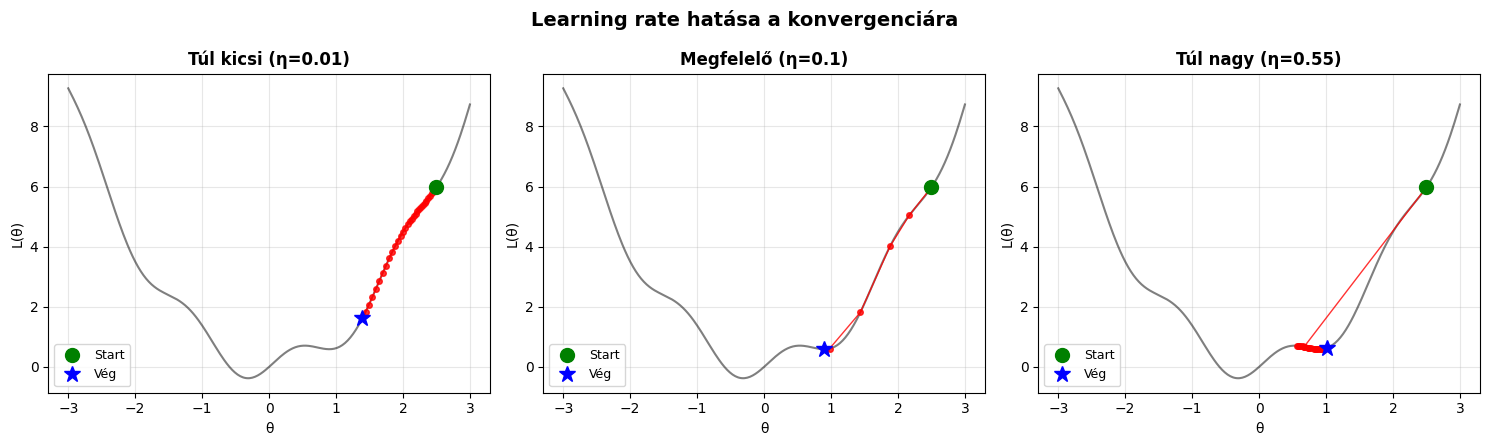

In [3]:
fig1, axes = plt.subplots(1, 3, figsize=(15, 4.5))
lrs = [0.01, 0.1, 0.55]
titles = ["Túl kicsi (η=0.01)", "Megfelelő (η=0.1)", "Túl nagy (η=0.55)"]

x_plot = np.linspace(-3, 3, 300)
for ax, lr, title in zip(axes, lrs, titles):
    ax.plot(x_plot, loss_1d(x_plot), "k-", linewidth=1.5, alpha=0.5)
    # GD lépések
    x_curr = 2.5
    trajectory = [x_curr]
    for _ in range(30):
        x_curr = x_curr - lr * grad_1d(x_curr)
        x_curr = np.clip(x_curr, -4, 4)
        trajectory.append(x_curr)
    traj = np.array(trajectory)
    ax.plot(traj, loss_1d(traj), "ro-", markersize=4, linewidth=1, alpha=0.8)
    ax.plot(traj[0], loss_1d(traj[0]), "go", markersize=10, zorder=5, label="Start")
    ax.plot(traj[-1], loss_1d(traj[-1]), "b*", markersize=12, zorder=5, label="Vég")
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("θ")
    ax.set_ylabel("L(θ)")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

fig1.suptitle("Learning rate hatása a konvergenciára", fontsize=14, fontweight="bold")
fig1.tight_layout()
fig1.savefig("04_learning_rate.png", dpi=150)
print("Ábra mentve: 04_learning_rate.png")

## 2. ábra: 2D loss surface (lokális minimum + nyeregpont)


In [4]:
def loss_2d(x, y):
    return x**2 - y**2  # nyeregpont az origóban

Ábra mentve: 04_saddle_point.png


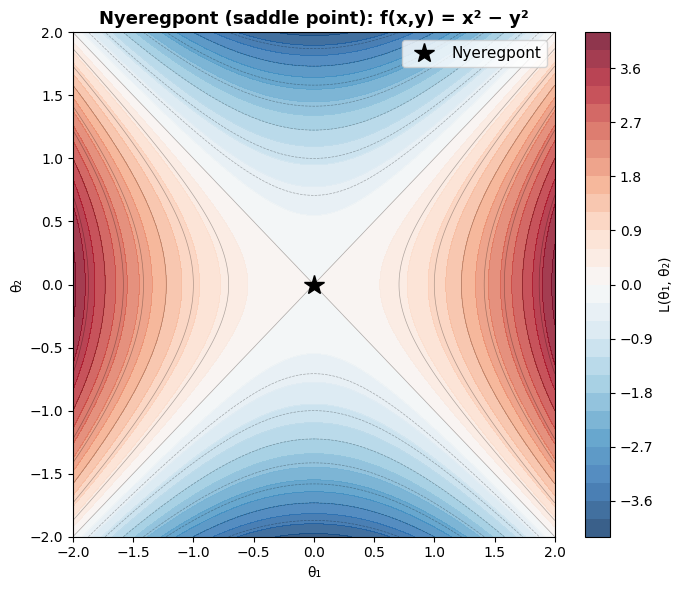

In [5]:
fig2, ax2 = plt.subplots(figsize=(7, 6))
xx, yy = np.meshgrid(np.linspace(-2, 2, 200), np.linspace(-2, 2, 200))
zz = loss_2d(xx, yy)
contour = ax2.contourf(xx, yy, zz, levels=30, cmap="RdBu_r", alpha=0.8)
ax2.contour(xx, yy, zz, levels=15, colors="k", linewidths=0.5, alpha=0.3)
plt.colorbar(contour, ax=ax2, label="L(θ₁, θ₂)")
ax2.plot(0, 0, "k*", markersize=15, label="Nyeregpont")
ax2.set_xlabel("θ₁")
ax2.set_ylabel("θ₂")
ax2.set_title("Nyeregpont (saddle point): f(x,y) = x² − y²", fontsize=13, fontweight="bold")
ax2.legend(fontsize=11)
fig2.tight_layout()
fig2.savefig("04_saddle_point.png", dpi=150)
print("Ábra mentve: 04_saddle_point.png")

## 3. ábra: Batch vs SGD vs Mini-batch


In [6]:
np.random.seed(42)
n_samples = 50
X_data = np.random.randn(n_samples, 1)
y_data = 3 * X_data + 1 + np.random.randn(n_samples, 1) * 0.5

def mse_loss(w, b, X, y):
    return np.mean((X * w + b - y)**2)

def mse_grad(w, b, X, y):
    err = X * w + b - y
    dw = 2 * np.mean(err * X)
    db = 2 * np.mean(err)
    return dw, db

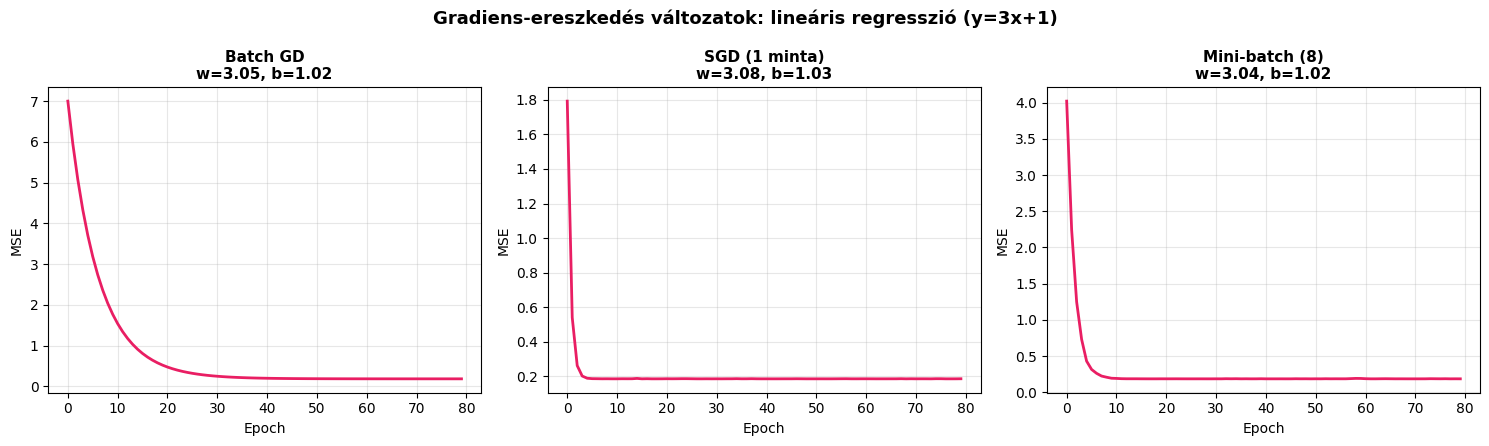

In [8]:
fig3, axes3 = plt.subplots(1, 3, figsize=(15, 4.5))
methods = [
    ("Batch GD", n_samples, 0.05),
    ("SGD (1 minta)", 1, 0.01),
    ("Mini-batch (8)", 8, 0.03),
]

for ax, (name, batch_size, lr) in zip(axes3, methods):
    w, b = 0.0, 0.0
    losses = []
    for epoch in range(80):
        indices = np.random.permutation(n_samples)
        for start in range(0, n_samples, batch_size):
            idx = indices[start:start + batch_size]
            dw, db = mse_grad(w, b, X_data[idx], y_data[idx])
            w -= lr * dw
            b -= lr * db
        losses.append(mse_loss(w, b, X_data, y_data))

    ax.plot(losses, linewidth=2, color="#E91E63")
    ax.set_title(f"{name}\nw={w:.2f}, b={b:.2f}", fontsize=11, fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MSE")
    ax.grid(True, alpha=0.3)

fig3.suptitle("Gradiens-ereszkedés változatok: lineáris regresszió (y=3x+1)", fontsize=13, fontweight="bold")
fig3.tight_layout()
fig3.savefig("04_gd_variants.png", dpi=150)
